# AI Judge Assistant — OCR Pipeline (Testing)

Simplified OCR pipeline for camera-captured Arabic legal documents.

**Pipeline layers:**
1. Document Ingestion — load PDF/image, convert to PIL Images
2. Image Restoration — RGB conversion, resize, CLAHE contrast normalization
3. Perspective Correction — DocTR-based document dewarping
4. OCR Engine — QARI (full-page, one call per page)
5. Text Reconstruction — numeral normalization, raw + normalized text
6. Output — structured JSON

## 0. Setup & Imports

Install all required packages and import everything the pipeline needs.
Run this cell once at the start of each session.

In [1]:
# ── Installs ──────────────────────────────────────────────────────────
!pip install -q transformers accelerate bitsandbytes huggingface-hub
!pip install -q qwen-vl-utils
!pip install -q "python-doctr[torch]"
!pip install -q pdf2image Pillow
!pip install -q opencv-python-headless

In [1]:
# ── Standard library ─────────────────────────────────────────────────
import json
import logging
import os
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# ── Third-party ───────────────────────────────────────────────────────
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2VLForConditionalGeneration
from qwen_vl_utils import process_vision_info
from doctr.models import detection_predictor

# ── Logging ────────────────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

print("All imports successful.")

All imports successful.


## 1. Configuration

All hardcoded pipeline variables live here: model name, file path, token,
max tokens. Edit this cell to point at your test document.

In [ ]:
# ── Model ─────────────────────────────────────────────────────────────
MODEL_NAME = "NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct"
MAX_NEW_TOKENS = 4000

# ── Input file ────────────────────────────────────────────────────────
# Change this to the path of your test document (image or PDF)
FILE_PATH = "E:\\Anaconda3\\envs\\Judge-Assistant\\Case Sample\\Case_Sample(5).jpeg"

# ── PDF conversion DPI (only used for PDF files) ─────────────────────
PDF_DPI = 400

# ── Image restoration ─────────────────────────────────────────────────
MAX_IMAGE_DIMENSION = 4000
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

# ── OCR prompt ────────────────────────────────────────────────────────
OCR_PROMPT = (
    "You are a strict OCR engine transcribing Arabic legal documents. "
    "Transcribe exactly what is written in this image. "
    "Do NOT correct spelling, grammar, punctuation, or any perceived mistakes. "
    "Do NOT add or remove any words. "
    "If something looks like a typo or error, transcribe it exactly as-is. "
    "Preserve all text exactly character by character."
)

# ── HuggingFace login ─────────────────────────────────────────────────
from huggingface_hub import login

if token := os.environ.get("HF_TOKEN"):
    login(token)
    print("HuggingFace login successful.")
else:
    print("HF_TOKEN not set — skipping login. Private models will not be accessible.")

print(f"Model: {MODEL_NAME}")
print(f"File:  {FILE_PATH}")

HF_TOKEN not set — skipping login. Private models will not be accessible.
Model: NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct
File:  E:\Anaconda3\envs\Judge-Assistant\Case Sample\Case_Sample(5).jpeg


## 2. Model Loading

Load the QARI OCR model with 8-bit quantization for memory efficiency.
This cell only needs to run once per session — all other cells reuse
the `model` and `processor` objects created here.

In [3]:
print(f"Loading QARI model: {MODEL_NAME}")

bnb_config = BitsAndBytesConfig(load_in_8bit=True)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
)

processor = AutoProcessor.from_pretrained(MODEL_NAME, use_fast=False)

print("QARI model loaded successfully.")

Loading QARI model: NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct


INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/dabe11e3990176858b26eacfef3ee16fff1d5970/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/dabe11e3990176858b26eacfef3ee16fff1d5970/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/dabe11e3990176858b26eacfef3ee16fff1d5970/generation_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/dabe11e3990176858b26eacfef3ee16fff1d5970/preprocessor_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404

QARI model loaded successfully.


## 3. Document Ingestion

Load the input file (PDF or image) and convert it to a list of PIL Images,
one per page. Single images become a one-element list.

In [9]:
SUPPORTED_IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".webp"}
SUPPORTED_PDF_EXTENSIONS = {".pdf"}


def ingest_document(file_path: str, pdf_dpi: int = 400) -> List[Image.Image]:
    """
    Load a PDF or image file and return a list of PIL Images (one per page).
    """
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"File does not exist: {path}")
    if not path.is_file():
        raise ValueError(f"Path is not a file: {path}")

    suffix = path.suffix.lower()

    if suffix in SUPPORTED_PDF_EXTENSIONS:
        from pdf2image import convert_from_path
        print(f"Converting PDF to images at {pdf_dpi} DPI: {path.name}")
        pil_pages = convert_from_path(str(path), dpi=pdf_dpi)
        # Ensure RGB
        pages = [p.convert("RGB") if p.mode != "RGB" else p for p in pil_pages]
        print(f"PDF converted: {len(pages)} page(s)")
        return pages

    elif suffix in SUPPORTED_IMAGE_EXTENSIONS:
        print(f"Loading image: {path.name}")
        img = Image.open(path)
        img.verify()
        img = Image.open(path)  # re-open after verify
        if img.mode != "RGB":
            img = img.convert("RGB")
        print(f"Image loaded: {img.size[0]}x{img.size[1]}")
        return [img]

    else:
        raise ValueError(f"Unsupported file type: {suffix}")


# ── Run ingestion ─────────────────────────────────────────────────────
pages = ingest_document(FILE_PATH, pdf_dpi=PDF_DPI)
print(f"\nTotal pages: {len(pages)}")
for i, p in enumerate(pages):
    print(f"  Page {i + 1}: {p.size[0]}x{p.size[1]}")

Loading image: Case_Sample(5).jpeg
Image loaded: 899x1599

Total pages: 1
  Page 1: 899x1599


## 4. Image Restoration

Lightweight preprocessing — no heavy denoising or learned models:
1. Ensure RGB mode
2. Resize if the largest dimension exceeds 4000 px (preserve aspect ratio)
3. Apply CLAHE contrast normalization

In [10]:
def restore_image(pil_image: Image.Image) -> Image.Image:
    """
    Lightweight image restoration:
    1. Convert to RGB if needed
    2. Resize if largest dimension > MAX_IMAGE_DIMENSION
    3. CLAHE contrast normalization
    """
    # 1. RGB conversion
    if pil_image.mode != "RGB":
        pil_image = pil_image.convert("RGB")

    # 2. Resize if too large
    w, h = pil_image.size
    max_dim = max(w, h)
    if max_dim > MAX_IMAGE_DIMENSION:
        scale = MAX_IMAGE_DIMENSION / max_dim
        new_w = int(w * scale)
        new_h = int(h * scale)
        pil_image = pil_image.resize((new_w, new_h), Image.LANCZOS)
        print(f"   Resized: {w}x{h} -> {new_w}x{new_h}")

    # 3. CLAHE contrast normalization
    img_array = np.array(pil_image)
    lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)
    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=CLAHE_TILE_GRID_SIZE,
    )
    l_enhanced = clahe.apply(l_ch)
    merged = cv2.merge((l_enhanced, a_ch, b_ch))
    enhanced_rgb = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    return Image.fromarray(enhanced_rgb)


# ── Run restoration ───────────────────────────────────────────────────
restored_pages: List[Image.Image] = []
for i, page in enumerate(pages):
    print(f"Restoring page {i + 1}...")
    restored_pages.append(restore_image(page))

print(f"\nRestoration complete: {len(restored_pages)} page(s)")

Restoring page 1...

Restoration complete: 1 page(s)


## 5. Perspective Correction

These documents are camera-captured photos with tilt, perspective distortion,
and background noise. This layer uses DocTR's detection predictor to find
the document boundary and dewarp it.

If DocTR cannot detect a clear document boundary, the original image is
passed through unchanged (no crash).

In [11]:
# ── Perspective Correction ─────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="doctr")

from doctr.models import detection_predictor
import numpy as np
import cv2
from PIL import Image
from typing import Tuple, List

# Load DocTR detection predictor once
doctr_detector = detection_predictor(arch="db_resnet50", pretrained=True)


def order_points(pts: np.ndarray) -> np.ndarray:
    """
    Order four corner points as: top-left, top-right, bottom-right, bottom-left.
    """
    rect = np.zeros((4, 2), dtype=np.float32)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left: smallest sum
    rect[2] = pts[np.argmax(s)]   # bottom-right: largest sum
    d = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(d)]   # top-right: smallest diff
    rect[3] = pts[np.argmax(d)]   # bottom-left: largest diff
    return rect


def extract_geometry_points(result, w: int, h: int) -> list:
    """
    Extract all bounding box corner points from a DocTR result.
    This version handles the confirmed structure:
    result[0] = {'words': np.ndarray of shape (N, 5)}
    where each row is [x_min, y_min, x_max, y_max, confidence]
    """
    all_points = []
    page_data = result[0]

    if not isinstance(page_data, dict) or 'words' not in page_data:
        print(f"   Unexpected DocTR structure: {type(page_data)} — skipping.")
        return all_points

    for box in page_data['words']:
        x_min, y_min, x_max, y_max = (
            float(box[0]), float(box[1]),
            float(box[2]), float(box[3])
            # box[4] is confidence score — intentionally ignored
        )
        all_points.extend([
            [x_min * w, y_min * h],
            [x_max * w, y_min * h],
            [x_max * w, y_max * h],
            [x_min * w, y_max * h],
        ])

    return all_points


def perspective_correct(pil_image: Image.Image) -> Tuple[Image.Image, bool]:
    """
    Use DocTR to detect the document boundary and dewarp the image.
    Returns the corrected PIL Image and a boolean indicating 
    whether correction was applied.
    Falls through to original image on any failure.
    """
    img_array = np.array(pil_image)
    h, w = img_array.shape[:2]

    try:
        result = doctr_detector([img_array])

        # ── Diagnostic (comment out after confirming structure) ──────────
        print(f"   DocTR result type: {type(result)}")
        print(f"   DocTR result[0] type: {type(result[0])}")
        # ─────────────────────────────────────────────────────────────────

        all_points = extract_geometry_points(result, w, h)

        if not all_points:
            print("   DocTR detected no text regions — skipping perspective correction.")
            return pil_image, False

        all_points = np.array(all_points, dtype=np.float32)

        # Convex hull over all detected text corners
        hull = cv2.convexHull(all_points)
        hull_area = cv2.contourArea(hull)
        img_area = w * h

        if hull_area < img_area * 0.15:
            print(
                f"   Detected text area too small "
                f"({100 * hull_area / img_area:.1f}% of image) — skipping."
            )
            return pil_image, False

        # Approximate hull to quadrilateral
        epsilon = 0.02 * cv2.arcLength(hull, True)
        approx = cv2.approxPolyDP(hull, epsilon, True)

        if len(approx) == 4:
            src_pts = order_points(approx.reshape(4, 2))
        else:
            # Fall back to bounding rect if hull isn't a clean quad
            x, y, bw, bh = cv2.boundingRect(hull)
            src_pts = np.array([
                [x,      y     ],
                [x + bw, y     ],
                [x + bw, y + bh],
                [x,      y + bh],
            ], dtype=np.float32)

        # Destination rectangle dimensions
        dst_w = int(max(
            np.linalg.norm(src_pts[1] - src_pts[0]),
            np.linalg.norm(src_pts[2] - src_pts[3])
        ))
        dst_h = int(max(
            np.linalg.norm(src_pts[3] - src_pts[0]),
            np.linalg.norm(src_pts[2] - src_pts[1])
        ))

        if dst_w < 100 or dst_h < 100:
            print(f"   Dewarped dimensions too small ({dst_w}x{dst_h}) — skipping.")
            return pil_image, False

        dst_pts = np.array([
            [0,         0        ],
            [dst_w - 1, 0        ],
            [dst_w - 1, dst_h - 1],
            [0,         dst_h - 1],
        ], dtype=np.float32)

        M = cv2.getPerspectiveTransform(src_pts, dst_pts)
        warped = cv2.warpPerspective(
            img_array, M, (dst_w, dst_h),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(255, 255, 255),
        )

        print(f"   Perspective corrected: {w}x{h} → {dst_w}x{dst_h}")
        return Image.fromarray(warped), True

    except Exception as exc:
        print(f"   Perspective correction failed: {exc} — passing through original.")
        return pil_image, False


# ── Run perspective correction on all pages ────────────────────────────
corrected_pages: List[Image.Image] = []
page_corrections: List[bool] = []

for i, page in enumerate(restored_pages):
    print(f"Perspective correction — page {i + 1}...")
    corrected, was_corrected = perspective_correct(page)
    corrected_pages.append(corrected)
    page_corrections.append(was_corrected)
    if not was_corrected:
        print(f"   Page {i + 1}: passed through unchanged.")

print(f"\nPerspective correction complete: {len(corrected_pages)} page(s)")
print(f"Corrected: {sum(page_corrections)} / {len(page_corrections)}")

INFO: Using downloaded & verified file: C:\Users\seife\.cache\doctr\models\db_resnet50-79bd7d70.pt


Perspective correction — page 1...
   DocTR result type: <class 'list'>
   DocTR result[0] type: <class 'dict'>
   Perspective corrected: 899x1599 → 602x841

Perspective correction complete: 1 page(s)
Corrected: 1 / 1


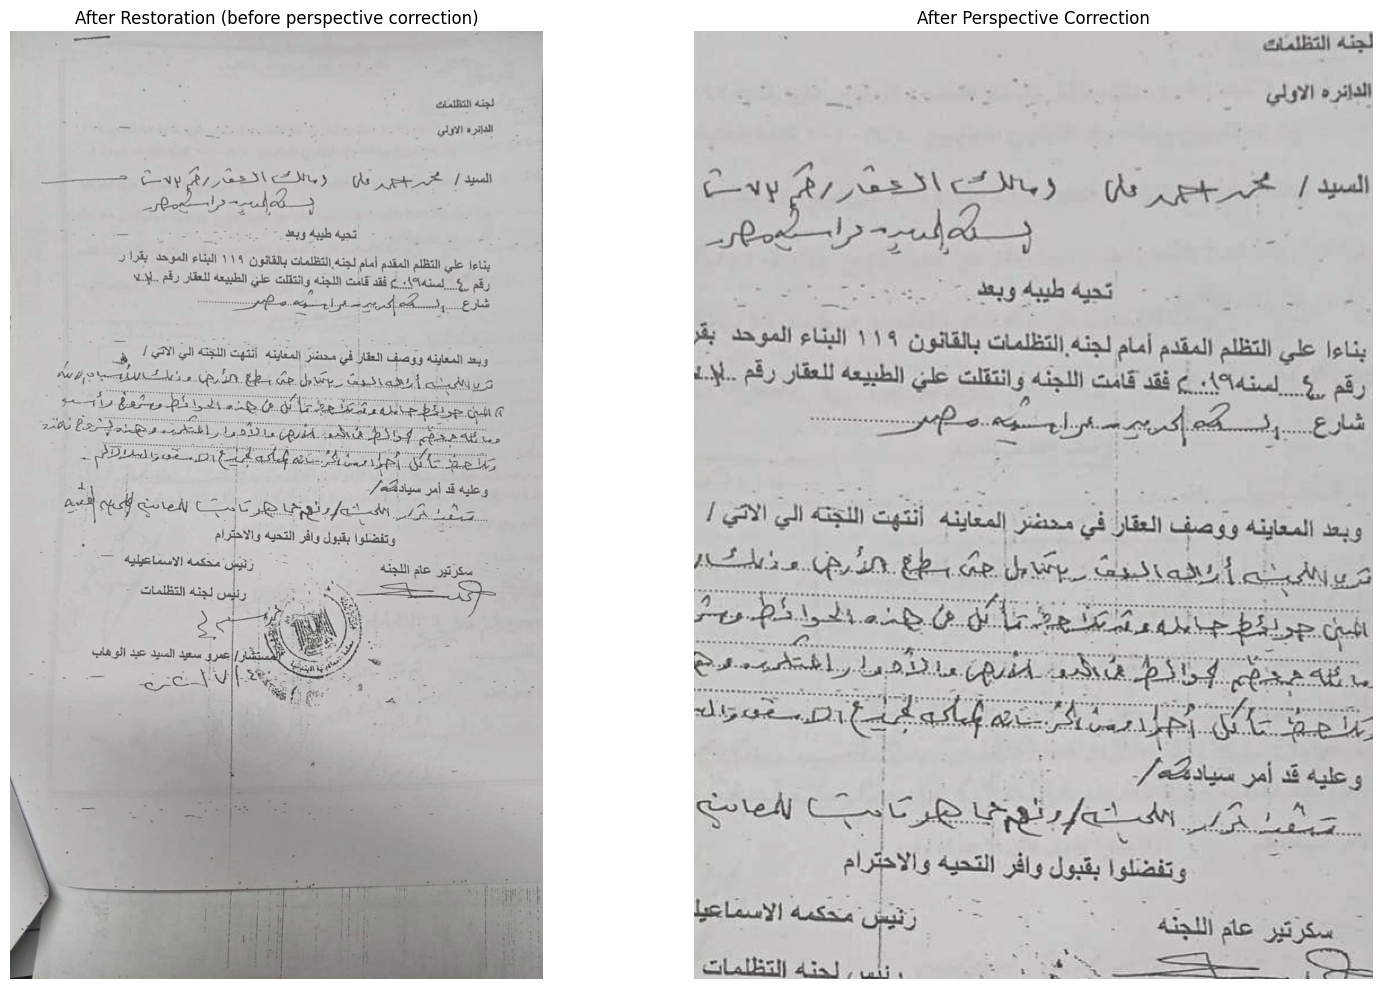

In [12]:
# Visual inspection cell
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
axes[0].imshow(restored_pages[0])
axes[0].set_title("After Restoration (before perspective correction)")
axes[0].axis("off")

axes[1].imshow(corrected_pages[0])
axes[1].set_title("After Perspective Correction")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
result = doctr_detector([np.array(restored_pages[0])])

page_data = result[0]
print("Keys:", page_data.keys())

# Look at the first item of each key
for key in page_data.keys():
    val = page_data[key]
    print(f"\nKey: '{key}'")
    print(f"  Type: {type(val)}")
    if isinstance(val, (list, np.ndarray)) and len(val) > 0:
        print(f"  Length: {len(val)}")
        print(f"  First item type: {type(val[0])}")
        print(f"  First item value: {val[0]}")
    else:
        print(f"  Value: {val}")

Keys: dict_keys(['words'])

Key: 'words'
  Type: <class 'numpy.ndarray'>
  Length: 32
  First item type: <class 'numpy.ndarray'>
  First item value: [0.34714787 0.58691406 0.38015004 0.59570312 0.30573058]


## 6. OCR Engine

Run QARI on each full page image. One inference call per page.
Includes a CUDA OOM error handler that logs the page and writes
an error entry to the output instead of crashing.

In [10]:
def ocr_page(pil_image: Image.Image, page_number: int) -> Dict[str, Any]:
    """
    Run QARI OCR on a single full-page PIL Image.

    Returns a dict with 'raw_text' or 'error'.
    """
    try:
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": pil_image},
                    {"type": "text", "text": OCR_PROMPT},
                ],
            }
        ]

        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
        )
        image_inputs, video_inputs = process_vision_info(messages)

        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to("cuda")

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

        generated_ids_trimmed = [
            out_ids[len(in_ids):]
            for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        output = processor.batch_decode(
            generated_ids_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]

        return {"raw_text": output.strip() if output else ""}

    except torch.cuda.OutOfMemoryError:
        logger.error("CUDA OOM on page %d — skipping.", page_number)
        torch.cuda.empty_cache()
        return {"error": "CUDA OOM \u2014 page skipped", "page": page_number}


# ── Run OCR on all pages ───────────────────────────────────────────────
ocr_results: List[Dict[str, Any]] = []

for i, page in enumerate(corrected_pages):
    page_num = i + 1
    print(f"OCR — page {page_num}/{len(corrected_pages)}...")

    t0 = time.time()
    result = ocr_page(page, page_num)
    elapsed = time.time() - t0

    ocr_results.append(result)
    print(f"Page {page_num} processed in {elapsed:.2f} seconds")

    if "error" in result:
        print(f"   ERROR: {result['error']}")
    else:
        text_len = len(result.get("raw_text", ""))
        preview = result.get("raw_text", "")[:120]
        print(f"   Text length: {text_len} chars")
        if preview:
            print(f"   Preview: {preview}...")

print(f"\nOCR complete: {len(ocr_results)} page(s) processed.")

OCR — page 1/1...
Page 1 processed in 686.31 seconds
   Text length: 5301 chars
   Preview: ولكنه التظلمات الدائره الاولي

السيد / محمد بن <b>وائل</b> <i>والمالك</i> <i>الجفر</i> <i>ريم</i> <u>وبي</u> <u>ل</u> <i...

OCR complete: 1 page(s) processed.


##### Logged Runs Time:
1. 6 mins 17 secs (Sample 4) 
    - Result: Almost all words were captured (problem in image preprocessing)
2. 10 mins 29 secs (Sample 2)
    - Result: Almost no words were captured (problem in model's tokens)
3. 4 mins 55 secs (Sample 1)
    - Result: Almost all words were captured (problem in image preprocessing)
4. 11 mins 26 secs (Sample 5)
    - Result: Almost no handwritten word were extracted right, printed words were extracted just fine


## 7. Text Reconstruction

Post-process the raw QARI output:
- Normalize Arabic-Indic and Persian numerals to Western digits
- Do NOT run any spell checking or grammar correction
- Store both the raw and normalized versions separately

In [13]:
def normalize_numerals(text: str) -> str:
    """
    Deterministic normalization of Arabic-Indic and Persian numerals
    to Western (ASCII) digits. No spell-checking or text correction.
    """
    arabic_indic = str.maketrans(
        '\u0660\u0661\u0662\u0663\u0664\u0665\u0666\u0667\u0668\u0669',
        '0123456789',
    )
    persian = str.maketrans(
        '\u06F0\u06F1\u06F2\u06F3\u06F4\u06F5\u06F6\u06F7\u06F8\u06F9',
        '0123456789',
    )
    text = text.translate(arabic_indic)
    text = text.translate(persian)
    return text


# ── Run reconstruction ─────────────────────────────────────────────────
reconstructed_pages: List[Dict[str, Any]] = []

for i, result in enumerate(ocr_results):
    page_num = i + 1

    if "error" in result:
        reconstructed_pages.append({
            "page_number": page_num,
            "perspective_corrected": page_corrections[i],
            "full_raw_text": "",
            "full_normalized_text": "",
            "error": result["error"],
        })
        continue

    raw_text = result.get("raw_text", "")
    normalized_text = normalize_numerals(raw_text)

    reconstructed_pages.append({
        "page_number": page_num,
        "perspective_corrected": page_corrections[i],
        "full_raw_text": raw_text,
        "full_normalized_text": normalized_text,
        "error": None,
    })

    print(f"Page {page_num}:")
    print(f"   Raw text length:        {len(raw_text)}")
    print(f"   Normalized text length:  {len(normalized_text)}")

print(f"\nReconstruction complete: {len(reconstructed_pages)} page(s)")

Page 1:
   Raw text length:        5301
   Normalized text length:  5301

Reconstruction complete: 1 page(s)


## 8. Output

Assemble the final structured JSON result and pretty-print it.

In [14]:
any_corrected = any(page_corrections)

output = {
    "metadata": {
        "filename": Path(FILE_PATH).name,
        "total_pages": len(reconstructed_pages),
        "model_used": MODEL_NAME,
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "perspective_corrected": any_corrected,
    },
    "pages": reconstructed_pages,
}

print(json.dumps(output, indent=2, ensure_ascii=False))

{
  "metadata": {
    "filename": "Case_Sample(5).jpeg",
    "total_pages": 1,
    "model_used": "NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct",
    "timestamp": "2026-03-26T13:27:33.873477+00:00",
    "perspective_corrected": true
  },
  "pages": [
    {
      "page_number": 1,
      "perspective_corrected": true,
      "full_raw_text": "ولكنه التظلمات الدائره الاولي\n\nالسيد / محمد بن <b>وائل</b> <i>والمالك</i> <i>الجفر</i> <i>ريم</i> <u>وبي</u> <u>ل</u> <i>كل</i> <i>إليسا</i> <i>مر</i> <u>لهم</u> <u>تر</u> <u>تحيه</u> طبيبه وبعد بناءا على <i>التظلم</i> المقدم أمام لجنه <i>التظلمات</i> بالقانون 9 11 <i>البناء</i> الموحد بـ <i>رقم</i> <u>“8”</u> لسنه “2013” <u>م</u> <u>فقد</u> قامت <i>اللجنة</i> وانتقلت على <i>الطبيعه</i> للعقار <i>رقم</i> <u>“13”</u> شارع <i>“1”</i> <u>و14”</u> <u>كم</u> <u>إكيم</u> <u>م</u> <u>مر</u> <u>لهمه</u> <i>ص</i> <i>همه</i> <u>……</u> <u>وبعد</u> <b>المعاينه</b> ووصف العقار في محضر <b>المعاينه</b> أنتهت <i>اللجنة</i> الي الاتي / <u>تم</u> <u>البحث</u> <b>أوائله</

# 1st Output

ولمن كل ما سبق <u>اولا:</u> <b>بطلان</b> <u>قرار</u> <b>الازالة</b> تاسيسما <u>على</u> <u>:</u> <i>:</i> <b>ا</b> - انعدام صفة <i>مقدم</i> <i>الطلب</i> <i>.</i> <i>2-</i> ادعاء <i>مقدم</i> <i>الطلب</i> ان الغقار فارغ. <i>3-</i> عدم <i>اعلان</i> القيمين <i>بالعقار</i> <i>.</i> <i>4-</i> عدم <i>معايير</i> العقار والدليل ان <i>الطالب</i> لم يرى اللجنة في اي وقت. <u>ثانيا:</u> <i>اساءة</i> استعمال السلطة لكل <u>من</u> <u>اول</u> <u>الطرف</u> <i>الثاني</i> الى <u>الطرف</u> <i>الخامس.</i> <u>ثالثا:</u> حالة العقار <i>حالة</i> جيدة جدا ولا <u>خوف</u> <u>على</u> سكانه، <u>رابعا:</u> مراعاة <i>كون</i> الرجل يزيدعن <u>السبعون</u> عاما <u>ولا</u> <u>يجوز</u> <i>القاءه</i> في <i>الشارع</i> الا بعد <i>التأكد</i> منه <u>منة</u> <u>بالمائنة</u> <u>من</u> <u>حالة</u> <u>العقار</u> <i>وحيث</i> وجود قرار سابق لم <u>يعلن</u> <u>بع</u> <u>الطالب</u> <u>بالترميم.</u> <u>لذلك</u> يلتمس <i>الطالب</i> <u>.</u> لا <u>:</u> قبل <i>الطعن</i> <i>شكلا</i> <i>.</i> <u>اثنا:</u> الحكم بصفة مستعجلة <u>وقف</u> تنفيذ القرار رقم 150 لسنة 2020 الصادر من لجنة <i>الظلمات</i> في تاريخ 4/7/2020 <b>طبعون</b> فيه وما يترتب عليه من <i>اثار</i> على <u>أن</u> يتم تنفيذه بمسودة الحكم <u>.</u> <u>وا</u> <u>ثنا:</u> وفي الموضوع الغاء القرار المطبعون فيه واعتباره كان لم يكن <i>والغاء</i> كافة <i>الاثار</i> المترتبة عليه وشمول الحكم بالنفا <b>جل</b> طليقا من قيد <i>الكفالة</i> مع الزام المطبعون ضدهم بالمصروفات واتعاب المحاماه. <b>مع</b> حفظ كافة الحقوق <i>الاخرى</i> <u>.</u> <u>وكيلة</u> <u>الطالب</u>

# 2nd Ouput 

<p>القضاء الإداري بالإسماعيلية <i>.</i></p><br><h3><b>تحية</b> طيبة <b>وبعد،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،،

# 3rd Output

<p><u>أولا:</u> بطلان القرار تأسيسا على <u>:</u> <u>م</u> <u>أ</u> <u>أن</u> <i>عدام</i> صفة مقدد <i>الطلب</i> الى <i>لجنة</i> التظلمات؟</p><br><p><i>المدعي</i> <b>عليه</b> <i>السابع</i> <i>ادعى</i> كونه مالكا <i>للعقار</i> ولم <i>يقدم</i> ما يثبت ادعاءه <b>وحيث</b> <i>ان</i> <i>التوكيل</i> لا يعتبر ناقلا <i>الملكية</i> <i>وحيث</i> ان المدعي <b>عليه</b> <i>السابع</i> لم <i>ثبت</i> له <b>ملكية</b> العقار حتى وقتنا هذا اذا فهو ليس ذو صفه ليتقدم باي <b>طلب</b> الى لجنة التظلمات ومادام <i>هو</i> ليس ذو صفه اذا خروج <i>اللجنة</i> اصلا <i>للماعينة</i> <i>باطل</i> فما <i>بني</i> على باطل فهو <i>باطل</i> .</p><br><p><u>ب:</u> <i>ادعى</i> <u>المدعي</u> <u>عليه</u> <u>السابع</u> <u>عند</u> <u>تقديم</u> <u>التظلم</u> ان العقار خالي من <u>السكان</u> <u>:</u> <i>ويجملة</i> الادعاءات <b>الباطلة</b> <i>التي</i> <i>قدمها</i> <i>المقابل</i> ادعاءه ان العقار <u>خالي</u> من السكان وهذا ما جعل اللجنة <b>تتهاون</b> في تقريرها <b>وتعديله</b> من <i>ترميم</i> الى <i>ازاله.</i></p><br><p><u>ج:</u> <i>عدم</i> <i>اعلن</i> اي من المقيمين في لبعقار <i>وذلك</i> لظنهم ان العقار خالي او لسبب <i>اخر</i> لا يعلمه <i>الا</i> <i>الله</i> ،فلم <i>يتسنى</i> <i>للطالب</i> او اي من المقيمين اتخاذ اي اجراء لايقاف <i>اصدار</i> القرار .</p><br><p><u>د:</u> عدم معاينة العقار ولا كانت <i>تعاملت</i> مع <i>الطالب</i> او اعلنته او علم اي شئ من كل تلك الاجراءات <i>.</i></p><br><p><u>ثانيا:</u> <u>اساءة</u> استعمال السلطة لكل من <i>اول</i> الطرف <u>الثاني</u> الى الطرف <i>الخامس</i> <u>مما</u> <u>يؤثر</u> <u>على</u> كافة <u>الاجراءات</u> <u>وتؤدي</u> <u>الى</u> <u>بطلاتها:</u> <u>.</u></p><br><p><i>وهذا</i> يبدو <i>جليا</i> حيث ان من الطرف <b>الثاني</b> الى الطرف <b>الخامس</b> بدءا من <i>اول</i> <u>:</u> <i>ا</i> - قبول طلب <i>الازالة</i> <i>والتظلم</i> من شخص لم يثبت كونه مالك العقار باي <i>وسيلة</i> <i>قانونية</i> حيث لا يعتبر <i>التوكيل</i> دليلي <i>ملكية</i> .</p><br><p>2 - عدم <i>اعلان</i> اي من <i>المقيمين</i> بالعقار او اعطاءهم الحق في اتخاذ اي من الاجراءات .</p><br><p>3 - <i>عدم</i> معاينة العقار او دخول اي من الشقق وخاصة <i>شقة</i> <i>الطالب</i> وهي بالدور <i>الارضي</i> والذي تم ذكره في التقرير مع انه لم <i>يدخل</i> اي من <i>اللجنة</i> الى تلك الشقة <u>فكيف</u> لها ان تكون قد عاينت <i>الدور</i> <i>الارضي.</i></p><br><h3><u>ثالثا:</u> <i>العقار</i> <u>محل</u> قرار الازالة <u>سليم</u> <u>ولا</u> <u>يوجد</u> <u>اي</u> <u>سبب</u> <u>للازالة</u> <u>:</u> <u>.</u></h3><br><p>بالرغم من عدم علم <i>الطالب</i> بالقرار الصادر من <i>اللجنة</i> بالترميم بحي ثان الاسماعيلية اللجنة <i>الاولى</i> رقم <u>4</u> لسنة 2019 <i>و</i> <i>الذي</i> صدر فيه قرار <i>بترميم</i> العقار واثبت انه لا خطورة على حياة ساكنيه.</p><br><h3>الا ان حالة العقار جيدة جدا وفي حالة وجود اي شئ يستحق <i>الترميم</i> سيتم ترميمه.</h3><br><h3>ومما <i>سبق</i> يتضح لذا ان الغرض وراء قرار الازالة ليس خوفا على <i>حياة</i> <i>أشخاص</i> ولكن رغبة في <i>ثراء</i> سريع ، فالقاء <i>رجل</i> كبير في <i>السن</i> تحدى <i>السبعون</i> من عمره عاش حياته <u>كلها</u> في تلك الشقة بالشارع وليس الا لرغبة في <b>حيازة</b> <i>المكان</i> وبناء <i>رج</i> سكني <b>مكانه</b> حيث ان هذا المنزل في احسن الامكان بالاسماعيلية .</h3>

# 4th Output

ولكنه التظلمات الدائره الاولي\n\nالسيد / محمد بن <b>وائل</b> <i>والمالك</i> <i>الجفر</i> <i>ريم</i> <u>وبي</u> <u>ل</u> <i>كل</i> <i>إليسا</i> <i>مر</i> <u>لهم</u> <u>تر</u> <u>تحيه</u> طبيبه وبعد بناءا على <i>التظلم</i> المقدم أمام لجنه <i>التظلمات</i> بالقانون 9 11 <i>البناء</i> الموحد بـ <i>رقم</i> <u>“8”</u> لسنه “2013” <u>م</u> <u>فقد</u> قامت <i>اللجنة</i> وانتقلت على <i>الطبيعه</i> للعقار <i>رقم</i> <u>“13”</u> شارع <i>“1”</i> <u>و14”</u> <u>كم</u> <u>إكيم</u> <u>م</u> <u>مر</u> <u>لهمه</u> <i>ص</i> <i>همه</i> <u>……</u> <u>وبعد</u> <b>المعاينه</b> ووصف العقار في محضر <b>المعاينه</b> أنتهت <i>اللجنة</i> الي الاتي / <u>تم</u> <u>البحث</u> <b>أوائله</b> <i>الدفء</i> <u>–</u> <i>بتشاور</i> <i>على</i> <i>مط</i> <i>د</i> <i>ربني</i> <i>وذلك</i> <i>المين</i> <i>جهود</i> <i>يجه</i> <i>الله</i> <i>مع</i> <i>تشاوره</i> <i>–</i> <i>ما</i> <i>كأن</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i> <i>ه</i>